## Introduction to TensorFlow

#### What is TensorFlow?
<li>TensorFlow is an end-to-end platform for machine learning.</li>
<li>Write fast Deep Learning code in Python/other accessible languages (able to run on a GPU/TPU). TPU is Tensor Processing Unit.</li>
<li>Able to access many pre-built deep learning models (TensorFlow Hub).</li>
<li>Whole Stack: preprocess data, model data, deploy model in your application.</li>
<li>Originally designed and use in-house by Google (it is now open-source).</li>

#### Why tensorFlow?
<li>Easy model building.</li>
<li>Robust ML production anywhere.</li>
<li>Powerfull experimentation for research.</li>

#### What is Tensor?
<li>Generally, tensors are some numerical way to represent information or some sort of data.</li>
Watch the video below from YouTube to underestand the Tensors:
<a>https://www.youtube.com/watch?v=f5liqUk0ZTw</a>
<li>Scientificly, tensors are arrays with more than two axes.</li>

<p>In this very first notebook, we are going to use some fundamental concepts of tensors using TensorFlow.

<ol>
    <li>Introduction to Tensors</li>
    <li>Getting information from Tensors</li>
    <li>Manipulating Tensors</li>
    <li>Tensors and Numpy</li>
    <li>Using @tf.function (a way to speed up the regular Python functions)</li>
    <li>Using GPUs with TensorFlow (or TPU)</li>
    <li>Exercises to try for yourself.</li>
</ol>



In [16]:
#Import tensorflow
import tensorflow as tf
print(tf.__version__)

2.7.0


In [17]:
# Creating Tensors with tf.constant()
scalar = tf.constant(10)
scalar

<tf.Tensor: shape=(), dtype=int32, numpy=10>

In [18]:
# Check the number of dimention of a tensor (ndim stands for the number of dimentions)
scalar.ndim

0

In [19]:
# Create a vector
vector = tf.constant([8, 7, 10])
vector

<tf.Tensor: shape=(3,), dtype=int32, numpy=array([ 8,  7, 10], dtype=int32)>

In [20]:
vector.ndim

1

In [21]:
#Create a matrix (a matrix have more than one dimention)
matrix = tf.constant([[9, 11],
                      [3, 6]])
matrix

<tf.Tensor: shape=(2, 2), dtype=int32, numpy=
array([[ 9, 11],
       [ 3,  6]], dtype=int32)>

In [22]:
matrix.ndim

2

In [23]:
matrix2 = tf.constant([[1, 2, 3, 4],
             [5, 6, 7, 8]])
matrix2

<tf.Tensor: shape=(2, 4), dtype=int32, numpy=
array([[1, 2, 3, 4],
       [5, 6, 7, 8]], dtype=int32)>

In [24]:
matrix2.ndim

2

In [25]:
matrix3 = tf.constant([[11., 8.],
                       [4., 6.,],
                       [2., 5.]], dtype = tf.float16) #Specify the data type with dtype parameter
matrix3

<tf.Tensor: shape=(3, 2), dtype=float16, numpy=
array([[11.,  8.],
       [ 4.,  6.],
       [ 2.,  5.]], dtype=float16)>

In [26]:
matrix3.ndim

2

In [27]:
# Let's create a tensor
tensor = tf.constant([[[3, 2, 7],
                      [4, 8, 9]],
                      [[10, 7, 4],
                      [11, 2, 3]],
                      [[13, 14, 15],
                      [16, 17, 18]]])
tensor

<tf.Tensor: shape=(3, 2, 3), dtype=int32, numpy=
array([[[ 3,  2,  7],
        [ 4,  8,  9]],

       [[10,  7,  4],
        [11,  2,  3]],

       [[13, 14, 15],
        [16, 17, 18]]], dtype=int32)>

In [28]:
tensor.ndim

3

####So far:

<li>Scalar: a single number or Rank 0 Tensor</li>
<li>Vector: a number with direction (e.g. wind speed and direction) or Rank 1 Tensor</li>
<li>Matrix: a 2-dimensional array of numbers</li>
<li>Tensor: an n-dimensional array of numbers or Rank n Tensor (e.g. RGB images in Convolutional Neural Networks.) --> n can be any number.</li>

### Creating tensors with tf.Variable()

In [29]:
# Create the same tensor with tf.Variable() as above
changeable_tensor = tf.Variable([12, 8])
unchangeable_tensor = tf.constant([12, 8])
changeable_tensor, unchangeable_tensor

(<tf.Variable 'Variable:0' shape=(2,) dtype=int32, numpy=array([12,  8], dtype=int32)>,
 <tf.Tensor: shape=(2,), dtype=int32, numpy=array([12,  8], dtype=int32)>)

In [30]:
# Let's try change one of the elements in the changeabe tensor
changeable_tensor[0] = 7

TypeError: ignored

In [31]:
# How about we try .assign()
changeable_tensor[0].assign(9)
changeable_tensor

<tf.Variable 'Variable:0' shape=(2,) dtype=int32, numpy=array([9, 8], dtype=int32)>

In [32]:
# Let's try the unchangeable tensor
unchangeable_tensor[0] = 17
unchangeable_tensor

TypeError: ignored

In [33]:
unchangeable_tensor[0].assign(17)
unchangeable_tensor

AttributeError: ignored

**Ponit**: Rarely in practice will you need to decide wether to use tf.constant or tf.Variable to create tensors, as TensorFlow does this for you. However, if in doubt, use tf.constant and change it later if needed.

### Creating Random Tensors
<p>Random Tensors are tensors of some arbitrary size which contain random numbers. </p>
<p>In order to train our Neural Network we need to Initialize with Random weights (only at the begining).

In [34]:
# Create random Tensors
random_1 = tf.random.Generator.from_seed(42) # set seed for reproducibility
random_1 = random_1.normal(shape = (3, 2))
random_2 = tf.random.Generator.from_seed(42)
random_2 = random_2.normal(shape = (3, 2))

# Are they equal? Yes, because we set a seed here.
random_1, random_2, random_1 == random_2

(<tf.Tensor: shape=(3, 2), dtype=float32, numpy=
 array([[-0.7565803 , -0.06854702],
        [ 0.07595026, -1.2573844 ],
        [-0.23193765, -1.8107855 ]], dtype=float32)>,
 <tf.Tensor: shape=(3, 2), dtype=float32, numpy=
 array([[-0.7565803 , -0.06854702],
        [ 0.07595026, -1.2573844 ],
        [-0.23193765, -1.8107855 ]], dtype=float32)>,
 <tf.Tensor: shape=(3, 2), dtype=bool, numpy=
 array([[ True,  True],
        [ True,  True],
        [ True,  True]])>)

### Shuffle the order of elements in a tensor
In other words, sometimes we interested in shuffling the dataset that we have

In [35]:
# Shuffle a tensor (valuabe when you want to shuffle your data so the inherent order does not effect learning process)
not_shuffled = tf.constant([[10, 7],
                            [4, 9],
                            [3, 10]])
not_shuffled

<tf.Tensor: shape=(3, 2), dtype=int32, numpy=
array([[10,  7],
       [ 4,  9],
       [ 3, 10]], dtype=int32)>

In [36]:
not_shuffled.ndim

2

In [37]:
# Shuffle our non_shuffled_tensor
# Use Shift + Command + Space to check the documentation or help in Google Colab or just use Shift + Tab command in Jupyter Notebook
tf.random.shuffle(not_shuffled)

<tf.Tensor: shape=(3, 2), dtype=int32, numpy=
array([[10,  7],
       [ 3, 10],
       [ 4,  9]], dtype=int32)>

In [38]:
# Run the cell again (we will get different order everytime that we run it.)
tf.random.shuffle(not_shuffled)

<tf.Tensor: shape=(3, 2), dtype=int32, numpy=
array([[ 4,  9],
       [ 3, 10],
       [10,  7]], dtype=int32)>

In [39]:
tf.random.shuffle(not_shuffled, seed = 42)

<tf.Tensor: shape=(3, 2), dtype=int32, numpy=
array([[ 3, 10],
       [ 4,  9],
       [10,  7]], dtype=int32)>

In [40]:
tf.random.shuffle(not_shuffled, seed = 42)

<tf.Tensor: shape=(3, 2), dtype=int32, numpy=
array([[ 3, 10],
       [ 4,  9],
       [10,  7]], dtype=int32)>

⚡If we use the Operation Level random Seed, everytime that we run the cell we will get a different result. However, if we use Global Level Random Seed we can get the same result.

**Important**: It looks like if want our shuffled tensors to be in the same order, we've got to use the global level random seed as well as the operation level random seed. 

In [41]:
tf.random.set_seed(42) # It is called the Global Level Random Seed 
tf.random.shuffle(not_shuffled, seed = 42) # This seed is called Operation Level Random Seed (based on the TensorFlow Documentation)

<tf.Tensor: shape=(3, 2), dtype=int32, numpy=
array([[10,  7],
       [ 4,  9],
       [ 3, 10]], dtype=int32)>

### Other ways to create tensors:

In [42]:
# Create a Tensor with all ones
tf.ones([5, 3])

<tf.Tensor: shape=(5, 3), dtype=float32, numpy=
array([[1., 1., 1.],
       [1., 1., 1.],
       [1., 1., 1.],
       [1., 1., 1.],
       [1., 1., 1.]], dtype=float32)>

In [43]:
# Create a tensor of all zeroes
tf.zeros(shape = (5, 3))

<tf.Tensor: shape=(5, 3), dtype=float32, numpy=
array([[0., 0., 0.],
       [0., 0., 0.],
       [0., 0., 0.],
       [0., 0., 0.],
       [0., 0., 0.]], dtype=float32)>

### Turn NumPy arrays into Tensors

The main difference between NumPy arrays and TensorFlow tensors is that Tensors can be run on a GPU (much faster for numerical computing). Otherwise they are very similar. 

In [44]:
# You can also turn NumPy arrays into Tensors
# Import NumPy
import numpy as np
numpy_A = np.arange(1, 25, dtype = np.int32) # Create a NumPy array between 1 and 25
numpy_A

# X = tf.constant(some_matrix) # Conventionally, Capital letter is used for matrix or Tensor
# y = tf.constant(vector) # None_capital letter is used for Vector 

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23, 24], dtype=int32)

In [45]:
A = tf.constant(numpy_A) # We just converted the NumPy array to form of a Tensor by passing it into tf.constant()
A

<tf.Tensor: shape=(24,), dtype=int32, numpy=
array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23, 24], dtype=int32)>

In [46]:
A.ndim

1

In [47]:
A = tf.constant(numpy_A, shape = (2, 3, 4))
B = tf.constant(numpy_A)

A, B

(<tf.Tensor: shape=(2, 3, 4), dtype=int32, numpy=
 array([[[ 1,  2,  3,  4],
         [ 5,  6,  7,  8],
         [ 9, 10, 11, 12]],
 
        [[13, 14, 15, 16],
         [17, 18, 19, 20],
         [21, 22, 23, 24]]], dtype=int32)>,
 <tf.Tensor: shape=(24,), dtype=int32, numpy=
 array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
        18, 19, 20, 21, 22, 23, 24], dtype=int32)>)

In [48]:
2 * 3 * 4 # For example, we cannot say 2 * 3 * 5 = 30. We'll get error because the shape should be same as the original shape. 
#In other words, we have 24 elements not 30.

24

In [49]:
2 * 3 * 5

30

In [50]:
C = tf.constant(numpy_A, shape = (3, 8)) # It also works because it is equal to 24 again.
D = tf.constant(numpy_A)

C, D

(<tf.Tensor: shape=(3, 8), dtype=int32, numpy=
 array([[ 1,  2,  3,  4,  5,  6,  7,  8],
        [ 9, 10, 11, 12, 13, 14, 15, 16],
        [17, 18, 19, 20, 21, 22, 23, 24]], dtype=int32)>,
 <tf.Tensor: shape=(24,), dtype=int32, numpy=
 array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
        18, 19, 20, 21, 22, 23, 24], dtype=int32)>)

In [51]:
3 * 8

24

## Getting information from Tensors
Most important tensor terms: 
<br>
when dealing with tensors you probably want to be aware of the following attributes:

**Shape** The length (number of elements) of each of the dimensions of a tensor. --> tensor.shape
<br>
**Rank** The number of tensor dimentions. 
<br>
**Axis or Dimention** A particulat dimension of a tensor
<br>
**Size** The total number of items in the tensor --> tf.size(tensor)
<br>

In [52]:
tf.size(A)

<tf.Tensor: shape=(), dtype=int32, numpy=24>

In [53]:
# Create a rank 4 tensor (4 dimentions)
rank_4_tensor = tf.zeros(shape = [2, 3, 4, 5])
rank_4_tensor

<tf.Tensor: shape=(2, 3, 4, 5), dtype=float32, numpy=
array([[[[0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0.]],

        [[0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0.]],

        [[0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0.]]],


       [[[0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0.]],

        [[0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0.]],

        [[0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0.]]]], dtype=float32)>

In [54]:
rank_4_tensor.shape, rank_4_tensor.ndim, tf.size(rank_4_tensor)

(TensorShape([2, 3, 4, 5]), 4, <tf.Tensor: shape=(), dtype=int32, numpy=120>)

In [55]:
2 * 3 * 4 * 5

120

In [56]:
# Get various attributes of our tensor
print("Datatype of every element: ", rank_4_tensor.dtype)
print("Number of dimensions (rank): ", rank_4_tensor.ndim)
print("Shape of tensor: ", rank_4_tensor.shape)
print("Elements along the 0 axis: ", rank_4_tensor.shape[0])
print("Elemets along the last axis: ", rank_4_tensor.shape[-1])
print("Total number of elemets in our tensor: ", tf.size(rank_4_tensor))
print("Total number of elemets in our tensor: ", tf.size(rank_4_tensor).numpy())

Datatype of every element:  <dtype: 'float32'>
Number of dimensions (rank):  4
Shape of tensor:  (2, 3, 4, 5)
Elements along the 0 axis:  2
Elemets along the last axis:  5
Total number of elemets in our tensor:  tf.Tensor(120, shape=(), dtype=int32)
Total number of elemets in our tensor:  120


## Indexing tensors

Tensors can be indexed just like python lists.


In [57]:
some_list = [1, 2, 3, 4]
some_list[:2]

[1, 2]

In [58]:
# Get te first 2 elemets of each dimension
rank_4_tensor[:2, :2, :2, :2]

<tf.Tensor: shape=(2, 2, 2, 2), dtype=float32, numpy=
array([[[[0., 0.],
         [0., 0.]],

        [[0., 0.],
         [0., 0.]]],


       [[[0., 0.],
         [0., 0.]],

        [[0., 0.],
         [0., 0.]]]], dtype=float32)>

In [59]:
# Get the first element from each dimension from each index except for the final one
rank_4_tensor[:1, :1, :1]

<tf.Tensor: shape=(1, 1, 1, 5), dtype=float32, numpy=array([[[[0., 0., 0., 0., 0.]]]], dtype=float32)>

In [60]:
rank_4_tensor[:1, :1, :1, :] # The last colon means get the whole thing

<tf.Tensor: shape=(1, 1, 1, 5), dtype=float32, numpy=array([[[[0., 0., 0., 0., 0.]]]], dtype=float32)>

In [61]:
rank_4_tensor[:1, :1, :, :1]

<tf.Tensor: shape=(1, 1, 4, 1), dtype=float32, numpy=
array([[[[0.],
         [0.],
         [0.],
         [0.]]]], dtype=float32)>

In [62]:
# Create a rank 2 tensor (2 dimensions)

rank_2_tensor = tf.constant([[14, 9], 
                             [2, 5]])
rank_2_tensor.shape, rank_2_tesnor.ndim

NameError: ignored

In [63]:
# Get the last item of each of row of our rank 2 tensor
rank_2_tensor[:, -1]

<tf.Tensor: shape=(2,), dtype=int32, numpy=array([9, 5], dtype=int32)>

In [64]:
# Add in extra dimension to our rank 2 tensor
rank_3_tensor = rank_2_tensor[..., tf.newaxis]
rank_3_tensor

<tf.Tensor: shape=(2, 2, 1), dtype=int32, numpy=
array([[[14],
        [ 9]],

       [[ 2],
        [ 5]]], dtype=int32)>

In [65]:
# Alternative to tf.newaxis
tf.expand_dims(rank_2_tesnor, axis = -1) # '-1' means expand the final axis 

NameError: ignored

In [66]:
tf.expand_dims(rank_2_tensor, axis = 0) # Extra dimention at the begining 

<tf.Tensor: shape=(1, 2, 2), dtype=int32, numpy=
array([[[14,  9],
        [ 2,  5]]], dtype=int32)>

In [67]:
rank_2_tensor

<tf.Tensor: shape=(2, 2), dtype=int32, numpy=
array([[14,  9],
       [ 2,  5]], dtype=int32)>

## Manipulating tensors(tensor operations)
### Basic operations
'+', '-', '*', '/'

In [68]:
# You can add values to a tensor using the addition operator
tensor = tf.constant([[3, 5], [7, 9]])
tensor + 10

<tf.Tensor: shape=(2, 2), dtype=int32, numpy=
array([[13, 15],
       [17, 19]], dtype=int32)>

In [69]:
# Original tensor is unchanged
tensor

<tf.Tensor: shape=(2, 2), dtype=int32, numpy=
array([[3, 5],
       [7, 9]], dtype=int32)>

In [70]:
# Multiplication also works
tensor * 10

<tf.Tensor: shape=(2, 2), dtype=int32, numpy=
array([[30, 50],
       [70, 90]], dtype=int32)>

In [71]:
# Subtraction if you want
tensor - 10

<tf.Tensor: shape=(2, 2), dtype=int32, numpy=
array([[-7, -5],
       [-3, -1]], dtype=int32)>

In [72]:
# We can use the tensorflow built-in function too (search for it)
tf.multiply(tensor, 10)

<tf.Tensor: shape=(2, 2), dtype=int32, numpy=
array([[30, 50],
       [70, 90]], dtype=int32)>

### Matrix multiplication
In machine learning, matrix multiplication is one of the most common tensor operations. The previous operation is known as element-wise operations.
<br>
Check the <a>matrixmultiplication.xyz</a>

In [73]:
# Matrix multiplication in tensorflow
print(tensor)
tf.matmul(tensor, tensor)

tf.Tensor(
[[3 5]
 [7 9]], shape=(2, 2), dtype=int32)


<tf.Tensor: shape=(2, 2), dtype=int32, numpy=
array([[ 44,  60],
       [ 84, 116]], dtype=int32)>

In [74]:
tensor * tensor # it is the element wise multiplication

<tf.Tensor: shape=(2, 2), dtype=int32, numpy=
array([[ 9, 25],
       [49, 81]], dtype=int32)>

In [75]:
# Matrix multiplication with Python operator "@"

tensor @ tensor

<tf.Tensor: shape=(2, 2), dtype=int32, numpy=
array([[ 44,  60],
       [ 84, 116]], dtype=int32)>

In [76]:
tensor.shape

TensorShape([2, 2])

In [77]:
# create a tensor of (3, 2) tenor
x = tf.constant([[1, 2],
                 [3, 4],
                 [5, 6]])

# create another (3, 2) tensor
y = tf.constant([[7, 8],
                 [9, 10],
                 [11, 12]])

x, y

(<tf.Tensor: shape=(3, 2), dtype=int32, numpy=
 array([[1, 2],
        [3, 4],
        [5, 6]], dtype=int32)>, <tf.Tensor: shape=(3, 2), dtype=int32, numpy=
 array([[ 7,  8],
        [ 9, 10],
        [11, 12]], dtype=int32)>)

In [78]:
# Try to matrix multiply of the same shape

x @ y

InvalidArgumentError: ignored

In [79]:
tf.matmul(x, y)

InvalidArgumentError: ignored

📖 **Resource:** Info and example of matrix multiplication: https://www.mathsisfun.com/algebra/matrix-multiplying.html 

<br>

There are two rules our tensor (or matrices) need to fulfil if we're going to matrix multiply them:

1. The inner dimention must match 
2. The resulting matrix has the shape of the outer dimentions

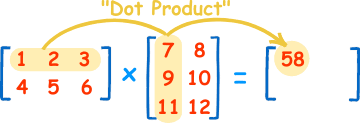

In [80]:
# Let's change the shape of y
tf.reshape(y, shape = (2, 3))

<tf.Tensor: shape=(2, 3), dtype=int32, numpy=
array([[ 7,  8,  9],
       [10, 11, 12]], dtype=int32)>

In [81]:
y

<tf.Tensor: shape=(3, 2), dtype=int32, numpy=
array([[ 7,  8],
       [ 9, 10],
       [11, 12]], dtype=int32)>

In [82]:
# Try to multiply x by reshaped y
x @ tf.reshape(y, shape = (2, 3))

<tf.Tensor: shape=(3, 3), dtype=int32, numpy=
array([[ 27,  30,  33],
       [ 61,  68,  75],
       [ 95, 106, 117]], dtype=int32)>

In [83]:
x.shape, tf.reshape(y, shape = (2, 3)).shape

(TensorShape([3, 2]), TensorShape([2, 3]))

In [84]:
tf.matmul(x, tf.reshape(y, shape = (2, 3)))

<tf.Tensor: shape=(3, 3), dtype=int32, numpy=
array([[ 27,  30,  33],
       [ 61,  68,  75],
       [ 95, 106, 117]], dtype=int32)>

In [85]:
tf.matmul(tf.reshape(x, shape = (2, 3)), y)

<tf.Tensor: shape=(2, 2), dtype=int32, numpy=
array([[ 58,  64],
       [139, 154]], dtype=int32)>

In [86]:
tf.reshape(x, shape = (2, 3)).shape, y.shape


(TensorShape([2, 3]), TensorShape([3, 2]))

### Transpose vs. Reshape
Transpose just flips the axises, whereas reshape just shuffle the tensor around into shape that you want.

In [87]:
# Can do the same with transpose
tf.transpose(x), tf.reshape(x, shape = (2, 3)) 

(<tf.Tensor: shape=(2, 3), dtype=int32, numpy=
 array([[1, 3, 5],
        [2, 4, 6]], dtype=int32)>,
 <tf.Tensor: shape=(2, 3), dtype=int32, numpy=
 array([[1, 2, 3],
        [4, 5, 6]], dtype=int32)>)

In [88]:
# Try matrix multiplication with transpose rather than reshape
tf.matmul(tf.transpose(x), y)

<tf.Tensor: shape=(2, 2), dtype=int32, numpy=
array([[ 89,  98],
       [116, 128]], dtype=int32)>

## Dot Product

Matrix multiplication is also known as the dot product. 

You can perform matrix multiplication using:
* tf.matmul()
*tf.tensordot()


In [90]:
# Perform the dot product on X and Y (requires X and Y to be tranposed)
X = tf.constant([[1, 2],
                 [3, 4],
                 [5, 6]])

Y = tf.constant([[7, 8],
                 [9, 10],
                 [11, 12]])

X, Y

(<tf.Tensor: shape=(3, 2), dtype=int32, numpy=
 array([[1, 2],
        [3, 4],
        [5, 6]], dtype=int32)>, <tf.Tensor: shape=(3, 2), dtype=int32, numpy=
 array([[ 7,  8],
        [ 9, 10],
        [11, 12]], dtype=int32)>)

In [91]:
tf.matmul(X, tf.transpose(Y))

<tf.Tensor: shape=(3, 3), dtype=int32, numpy=
array([[ 23,  29,  35],
       [ 53,  67,  81],
       [ 83, 105, 127]], dtype=int32)>

In [95]:
tf.tensordot(X, tf.transpose(Y), axes = 1)

<tf.Tensor: shape=(3, 3), dtype=int32, numpy=
array([[ 23,  29,  35],
       [ 53,  67,  81],
       [ 83, 105, 127]], dtype=int32)>

In [96]:
# Perform matrix multiplication between X and Y (transposed)
tf.tensordot(tf.transpose(X), Y, axes = 1)

<tf.Tensor: shape=(2, 2), dtype=int32, numpy=
array([[ 89,  98],
       [116, 128]], dtype=int32)>

In [97]:
tf.matmul(tf.transpose(X), Y)

<tf.Tensor: shape=(2, 2), dtype=int32, numpy=
array([[ 89,  98],
       [116, 128]], dtype=int32)>

In [98]:
tf.matmul(tf.reshape(X, shape = (2, 3)), Y)

<tf.Tensor: shape=(2, 2), dtype=int32, numpy=
array([[ 58,  64],
       [139, 154]], dtype=int32)>

In [103]:
# Check the value of Y, reshape Y and transpose of Y
print('Normal Y: ', Y)
print('\n')
print('Y transpose: ', tf.transpose(Y))
print('\n')
print('Y reshaped: ', tf.reshape(Y, shape = (2, 3)))

Normal Y:  tf.Tensor(
[[ 7  8]
 [ 9 10]
 [11 12]], shape=(3, 2), dtype=int32)


Y transpose:  tf.Tensor(
[[ 7  9 11]
 [ 8 10 12]], shape=(2, 3), dtype=int32)


Y reshaped:  tf.Tensor(
[[ 7  8  9]
 [10 11 12]], shape=(2, 3), dtype=int32)


Generally, when performing matrix multiplication on two tensors and one of the axes doesn't line up, you will transpose (rather that reshape) one of the tensors to get satisfy the matrix multiplication rules. 